# Superstore Sales Workflow Tutorial

This notebook walks through cleaning the Superstore dataset, designing a relational structure, creating an SQLite database, and running example SQL queries and visualizations.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

## 1️) Load and Inspect the Dataset

In [2]:
# reading error codes + research is how you can learn if there is different encoding, as seen below
df = pd.read_csv('../data/Superstore.csv', encoding='ISO-8859-1')
df.head()
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

### Double check some datatypes, and for nulls and duplicates:

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

This data is incredibly clean - we can see there are no null values and no duplicates. However, there are some dates that could be saved in a better format.

## 2) Data Cleaning

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [8]:
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [9]:
df.Segment.unique()

<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

In [10]:
df.rename(columns={"Segment":"customer_category"}, inplace=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,customer_category,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


With real data, it is very likely more cleaning and wrangling would be required. 

## 3) Build Relational Tables

In [11]:
conn = sqlite3.connect('../data/superstore.db')

customers_df = df[['Customer ID','Customer Name','customer_category','City','State','Region', 'Postal Code']].drop_duplicates().rename(columns={
    'Customer ID':'customer_id',
    'Customer Name':'customer_name',
    'City':'city',
    'State':'state',
    'Region':'region',
    'Postal Code': 'zipcode'
})

products_df = df[['Product ID','Category','Sub-Category','Product Name']].drop_duplicates().rename(columns={
    'Product ID':'product_id',
    'Category':'category',
    'Sub-Category':'subcategory',
    'Product Name':'product_name'
})

orders_df = df[['Order ID','Order Date','Ship Date','Ship Mode','Customer ID']].drop_duplicates().rename(columns={
    'Order ID':'order_id',
    'Order Date':'order_date',
    'Ship Date':'ship_date',
    'Ship Mode':'ship_mode',
    'Customer ID':'customer_id'
})

order_details_df = df[['Order ID','Product ID','Sales','Quantity','Discount','Profit']].rename(columns={
    'Order ID':'order_id',
    'Product ID':'product_id'
})


customers_df.to_sql('customers', conn, index=False, if_exists='replace')
products_df.to_sql('products', conn, index=False, if_exists='replace')
orders_df.to_sql('orders', conn, index=False, if_exists='replace')
order_details_df.to_sql('order_details', conn, index=False, if_exists='replace')
conn.commit()

In [12]:
for name, df in [
    ('customers', customers_df),
    ("products", products_df),
    ("orders", orders_df),
    ("order_details", order_details_df)
]:
    df.to_csv(f'../data/{name}.csv')

## 4) Make Some Queries!

### Which customer segments bring in the most revenue and profit?

In [13]:
query1 = """ SELECT 
    c.customer_category,
    ROUND(SUM(od.sales), 2) AS total_sales,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_category
ORDER BY total_sales DESC;
"""
result1 = pd.read_sql(query1, conn)
result1

,customer_category,total_sales,total_profit
0,Consumer,8380282.43,973085.86
1,Corporate,5044899.83,660287.69
2,Home Office,2964459.36,434344.01


### What are the top 10 customers by total sales?

In [15]:
query2 = """ SELECT
c.customer_name,ROUND(SUM(od.Sales),2) AS total_sales
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
JOIN order_details od ON o.order_id = od.order_id
GROUP BY c.customer_name
ORDER BY total_sales DESC
LIMIT 10
"""
result2 = pd.read_sql(query2, conn)
result2

,customer_name,total_sales
0,Ken Lonsdale,155927.52
1,Sanjit Engle,134303.82
2,Clay Ludtke,130566.55
3,Adrian Barton,130262.14
4,Sanjit Chand,127281.01
5,Sean Miller,125215.25
6,Edward Hooks,123730.56
7,Greg Tran,118201.20
8,Seth Vernon,114709.50
9,John Lee,107799.15


### Which product categories and subcategories are the most profitable overall?

In [67]:
query3 = """ SELECT
p.category, p.subcategory, 
ROUND(MAX(od.Sales),2) AS Maximum_Sales
FROM products p
JOIN order_details od ON p.product_id =od.product_id
GROUP BY p.category, p.subcategory
ORDER BY Maximum_Sales DESC

 """
result3 = pd.read_sql(query3, conn)
result3

,category,subcategory,Maximum_Sales
0,Technology,Machines,22638.48
1,Technology,Copiers,17499.95
2,Office Supplies,Binders,9892.74
3,Office Supplies,Supplies,8187.65
4,Technology,Phones,4548.81
5,Furniture,Chairs,4416.17
6,Furniture,Bookcases,4404.90
7,Furniture,Tables,4297.64
8,Technology,Accessories,3347.37
9,Office Supplies,Storage,2934.33


### What is the average discount given per category?

In [ ]:
query4 = """ 
SELECT 
p.category, ROUND(AVG(od.Discount), 4) as Average_Discount
FROM products p
JOIN order_details od ON p.product_id = od.product_id
GROUP BY p.category

"""
result4 = pd.read_sql(query4, conn)
result4

,category,Average_Discount
0,Furniture,0.1725
1,Office Supplies,0.1570
2,Technology,0.1330


### Which states or regions contribute the most to total sales?

In [22]:
query5 = """ SELECT
c.state, c.region, ROUND(SUM(od.Sales), 2) AS Total_Sales
FROM customers c
JOIN orders o ON o.customer_id = c.customer_id
JOIN order_details od ON od.order_id = o.order_id
GROUP BY c.state, c.region
ORDER BY Total_Sales DESC

 """
result5 = pd.read_sql(query5, conn)
result5

,state,region,Total_Sales
0,California,West,3314837.69
1,New York,East,1859365.37
2,Texas,Central,1547925.76
3,Pennsylvania,East,886105.68
4,Washington,West,862298.69
5,Illinois,Central,843352.76
6,Ohio,East,707747.69
7,Florida,South,635637.78
8,North Carolina,South,437938.43
9,Michigan,Central,432428.02


### How many orders were shipped late (where Ship Date > Order Date + 3 days)?

In [59]:

# query6 = """ SELECT
# DATE(ship_date) as Ship_date, DATE(order_date) as Order_date, COUNT(order_id) as Late_Orders
# FROM orders
# WHERE ship_date > Date(order_date,'+3 days') 
# GROUP BY ship_date, order_date
# ORDER BY Late_Orders DESC

# """
# result6 = pd.read_sql(query6, conn)
# result6 

# Changed the code for visualization purpose 

query6 = """
SELECT 
strftime('%Y-%m', ship_date) AS Ship_month,
COUNT(order_id) AS Late_Orders
FROM orders
WHERE ship_date > DATE(order_date, '+3 days')
GROUP BY Ship_month
ORDER BY Ship_month
"""
result6 = pd.read_sql(query6, conn)
result6

,Ship_month,Late_Orders
0,2011-01,19
1,2011-02,26
2,2011-03,51
3,2011-04,55
4,2011-05,52
5,2011-06,55
6,2011-07,55
7,2011-08,54
8,2011-09,98
9,2011-10,66


### Which month or year had the highest total sales?

In [30]:
query7 = """ 

SELECT
strftime('%m', o.order_date) as MONTH,
strftime('%Y', o.order_date) AS YEAR, 
ROUND(SUM(od.Sales), 2) AS Total_Sales
FROM orders o
JOIN order_details od ON o.order_id = od.order_id
GROUP BY MONTH, YEAR
ORDER BY Total_Sales DESC
LIMIT 1


 """
result7 = pd.read_sql(query7, conn)
result7

,MONTH,YEAR,Total_Sales
0,11,2014,112326.47


### What are the most frequently ordered products?

In [31]:
query8 = """ 

SELECT
p.product_name, COUNT(od.order_id) AS Order_Count
FROM products p 
JOIN order_details od on p.product_id = od.product_id
GROUP BY p.product_name
ORDER BY Order_Count DESC
LIMIT 5

 """
result8 = pd.read_sql(query8, conn)
result8

,product_name,Order_Count
0,Staples,227
1,Avery Non-Stick Binders,20
2,Xerox 1908,19
3,Xerox 1881,19
4,Logitech P710e Mobile Speakerphone,18


### Which customers placed more than 5 orders total?

In [32]:
query9 = """ 

SELECT 
c.customer_name, COUNT(o.order_id) AS Total_Orders
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_name
HAVING Total_orders >5
 """
result9 = pd.read_sql(query9, conn)
result9

,customer_name,Total_Orders
0,Aaron Bergman,9
1,Aaron Hawkins,49
2,Aaron Smayling,49
3,Adam Bellavance,64
4,Adam Hart,100
...,...,...
742,Xylona Preis,121
743,Yana Sorensen,64
744,Yoseph Carroll,25
745,Zuschuss Carroll,169


### What’s the profit margin (profit ÷ sales) by category or segment?

In [38]:
query10 = """ 

SELECT 
p.category, c.customer_category, 
ROUND(SUM(od.profit)/SUM(od.Sales)*100, 2) AS Profit_Margin
FROM products p
JOIN order_details od ON p.product_id = od.product_id
JOIN orders o ON o.order_id = od.order_id
JOIN customers c ON c.customer_id = o.customer_id
GROUP BY p.category, c.customer_category
ORDER BY Profit_Margin DESC

"""
result10 = pd.read_sql(query10, conn)
result10

,category,customer_category,Profit_Margin
0,Office Supplies,Home Office,22.70
1,Technology,Corporate,18.10
2,Technology,Home Office,17.26
3,Technology,Consumer,17.19
4,Office Supplies,Corporate,16.84
5,Office Supplies,Consumer,15.67
6,Furniture,Corporate,3.63
7,Furniture,Home Office,2.83
8,Furniture,Consumer,2.52


### 5) Visualize it!

From your ten results, select at least 4 to utilize in a meaningful visualization. 

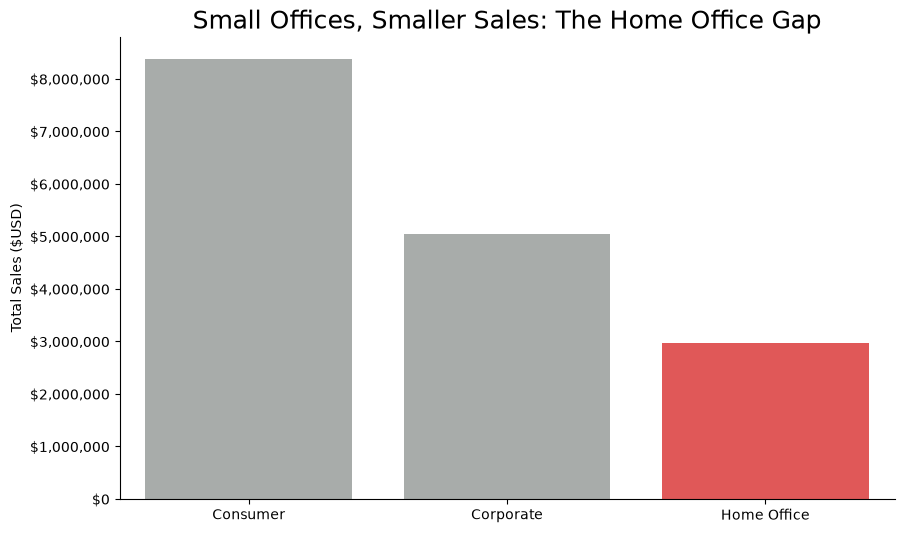

In [39]:
# example using result1
plt.figure(figsize=(10,6))
colors = ["#a7adaa", "#a7adaa", "#f74141" ]
sns.barplot(result1, x='customer_category', y='total_sales', palette=colors, hue='customer_category', legend=False)
plt.title('Small Offices, Smaller Sales: The Home Office Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()


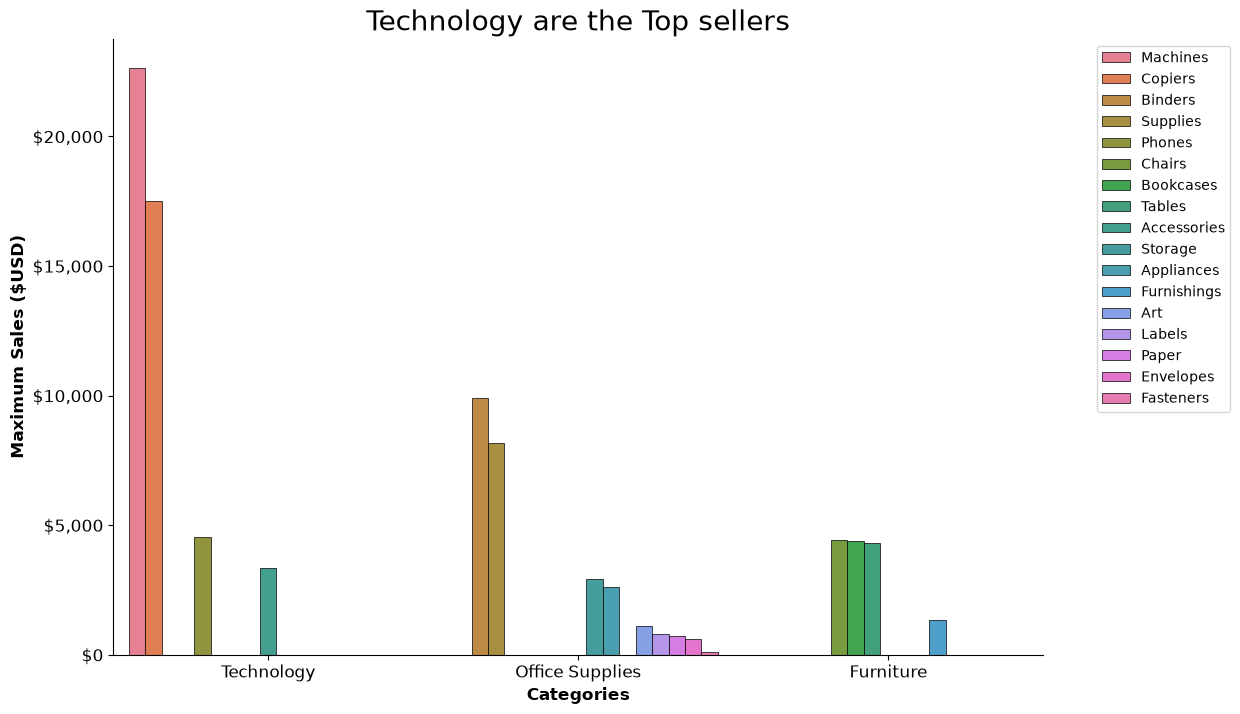

In [ ]:
# visualization one code here

#Technology are the Topsellers - Grouped Bar chart

plt.figure(figsize=(12, 8))
sns.barplot(result3, x='category', y='Maximum_Sales', hue='subcategory', width=0.9, edgecolor='black', linewidth=0.5)
plt.title('Technology are the Top sellers', fontsize=20)
plt.xlabel('Categories',fontsize=12,fontweight='bold')
plt.ylabel('Maximum Sales ($USD)', fontsize=12, fontweight='bold')
plt.ticklabel_format(style='plain', axis='y')

ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.show()




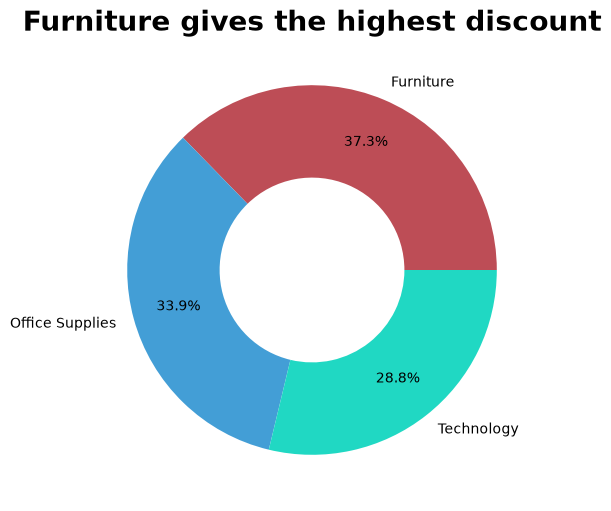

In [82]:
#visualization two code here
# Average Discount Per Category - Donut Chart
plt.figure(figsize=(10,6))

colors = ["#bd4d56", "#439ed6", "#20d8c3"] 
plt.pie(result4['Average_Discount'], labels=result4['category'], colors=colors, autopct='%1.1f%%',pctdistance=0.75, wedgeprops=dict(width=0.5))
plt.title('Furniture gives the highest discount', fontsize=20, fontweight='bold')

plt.show()



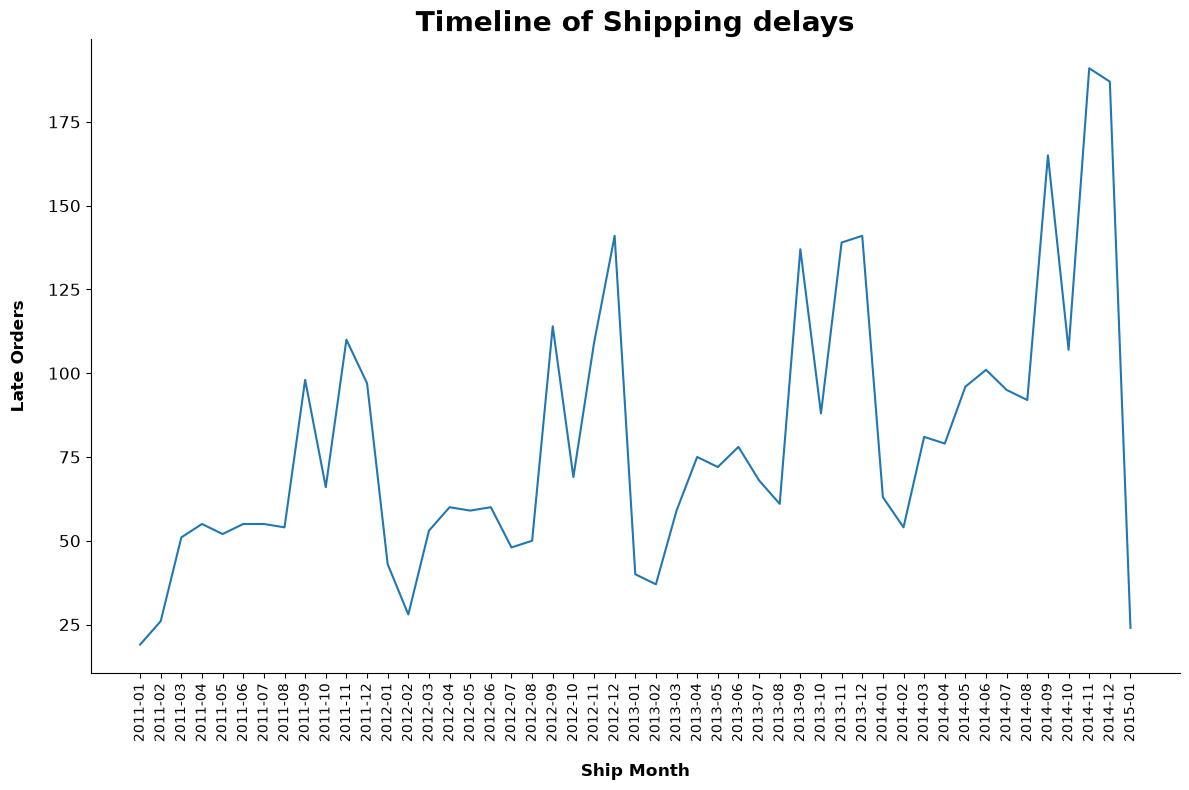

In [ ]:
# visualization three code here

#Shipping delay timeline - Line Chart

plt.figure(figsize=(12, 8))
sns.lineplot(result6, x='Ship_month', y='Late_Orders')
plt.title('Timeline of Shipping delays', fontsize=20, fontweight='bold')
plt.xlabel('Ship Month',fontsize=12,fontweight='bold',labelpad=15)
plt.ylabel('Late Orders', fontsize=12, fontweight='bold',labelpad=15)
plt.ticklabel_format(style='plain', axis='y')

ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=90, ha='center', fontsize=10)
plt.yticks(fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()


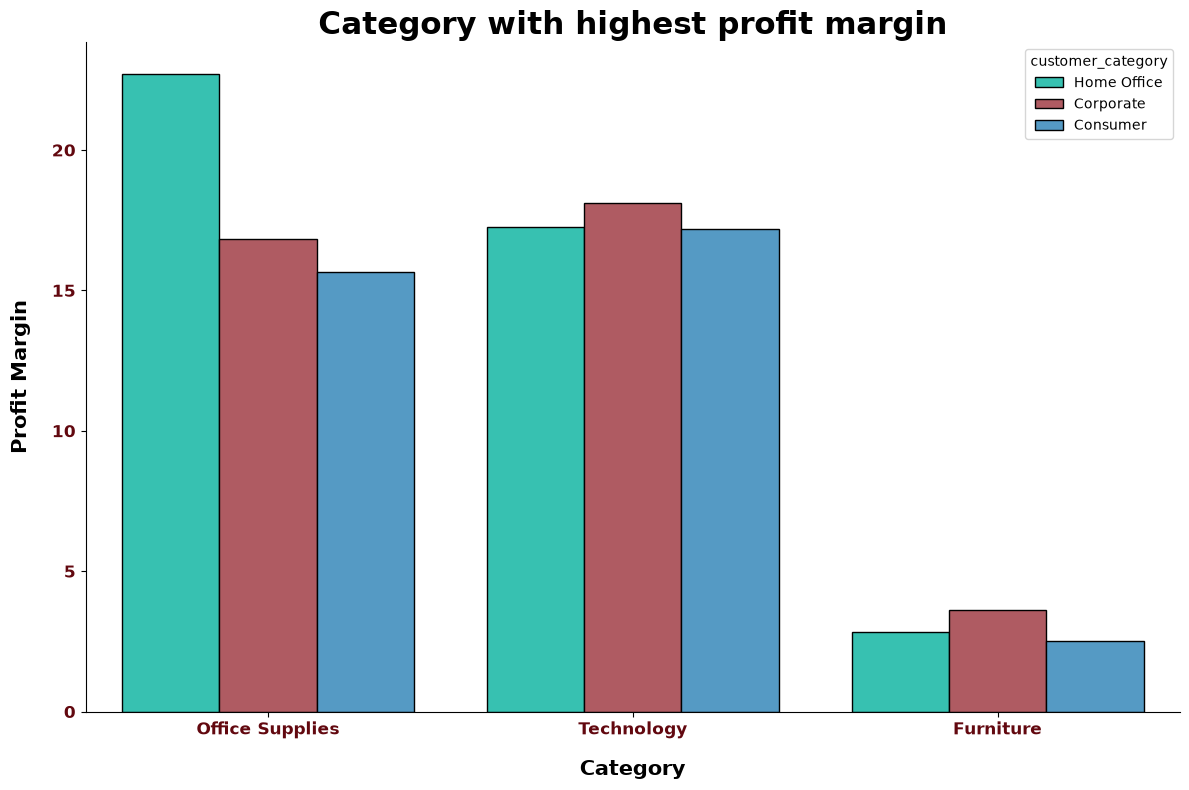

In [105]:
# visualization four code here
#Category with highest profit margin -Scatter plot
result10_sorted = result10.sort_values('Profit_Margin',ascending=False)

plt.figure(figsize=(12, 8))
colors = ["#20d8c3","#bd4d56", "#439ed6"]
sns.barplot(result10_sorted, x='category', y='Profit_Margin', hue='customer_category',edgecolor='black',palette=colors)
plt.title('Category with highest profit margin', fontsize=22, fontweight='bold')
plt.xlabel('Category',fontsize=15,fontweight='bold',labelpad=15)
plt.ylabel('Profit Margin', fontsize=15, fontweight='bold',labelpad=15)
plt.ticklabel_format(style='plain', axis='y')

ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(ha='center', fontsize=12,fontweight='bold', color="#62080f")
plt.yticks(fontsize=12,fontweight='bold', color="#62080f")

sns.despine()
plt.tight_layout()
plt.show()
